# Task 1a

## Data Splitting and Loading

The data normalization approach chosen was min-max normalization. Unlike standardization (z-score normalization), which transforms data based on mean and standard deviation, min-max normalization maintains relative differences between values and does not assume a Gaussian distribution.

For training and validation, dynamic generators were used as dataloaders, with two possible strategies considered. The first approach involved random start index selection, where a single starting index was randomly chosen within each event, which consists of 36 frames. From that point, 24 consecutive frames were selected, with the first 12 frames used as inputs and the next 12 frames used as targets for the model. This method introduces some variation in training while ensuring diverse sequences are extracted from each event. The second approach was a sliding window method, which captured all possible 12-frame input/output pairs within the 36-frame event. This method ensured complete coverage of every possible training pair, maximizing the available data but potentially introducing redundancy. Ultimately, the final choice of dataloader was based on balancing computer memory, dataset diversity, and model performance. We ended up using the second option, data augmentation for our model.

The dataset was split into 80% for training and 20% for validation, a common practice.


The result of input and output shape
- Input batch shape: (16, 12, 384, 384, 1)
- Output batch shape: (16, 12, 384, 384, 1)

## Models Considered Discussion

The task at hand involves predicting 12 future frames from 12 previous frames, requiring the model to capture both spatial and temporal dependencies. Given the spatiotemporal nature of the problem, we explored multiple architectures, leveraging convolutional networks and recurrent structures.

Convolutional layers serve as the primary building blocks for image-based tasks due to their effectiveness in extracting spatial features. However, our problem extends beyond static image processing—it requires modeling temporal relationships between frames. To address this, two main modeling strategies were explored:
- U-Net-Based Approach: This approach implicitly captures temporal dependencies by pooling together frame-wise spatial representations. While effective in some cases, it may not fully capture complex spatiotemporal dynamics.
- CNN-LSTM Hybrid Model: A widely used model for spatiotemporal tasks, this approach combines convolutional layers for spatial feature extraction with LSTMs (or ConvLSTMs) to model sequential dependencies. https://rsree.ise.illinois.edu/Machine_Learning_&_Data_Analytics_files/ACPR_2019_paper_242.pdf

The Unet model can be found in branch task1. Loss achieved at 5 epochs was 0.048334. Images for the first frames predicted showed quite a bit of resemblance to the real ones, but it was clear that latter frames were prediced less well. In order to remedy this, an explicit wat to capture temporal dependencies was chosen.

## 2DUnet Model

Model Structure: U-Net
- Input: The model takes 12 input frames of size 384x384.
- Encoding (Downsampling):
Three convolutional layers, each followed by max pooling to reduce the size and extract features.
- Bottleneck: A convolutional layer at the deepest part of the network.
- Decoding (Upsampling):
Three transpose convolution layers (ConvTranspose2d) to upsample the feature maps.
Skip connections combine features from the encoder.
- Output: A final convolutional layer to output 12 frames of size 384x384.

Training process

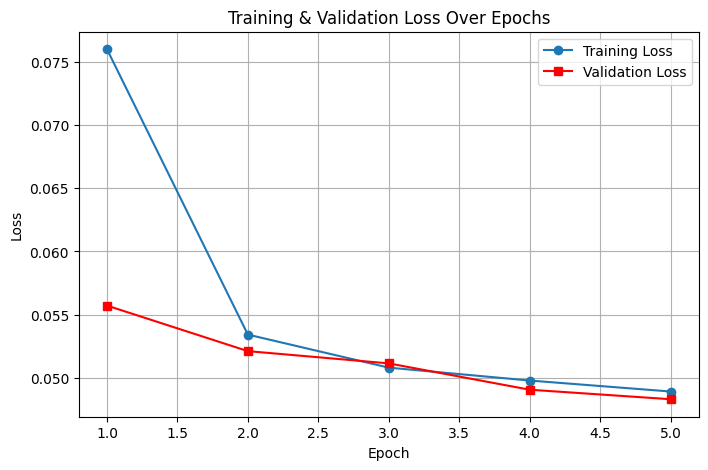

Training Result:

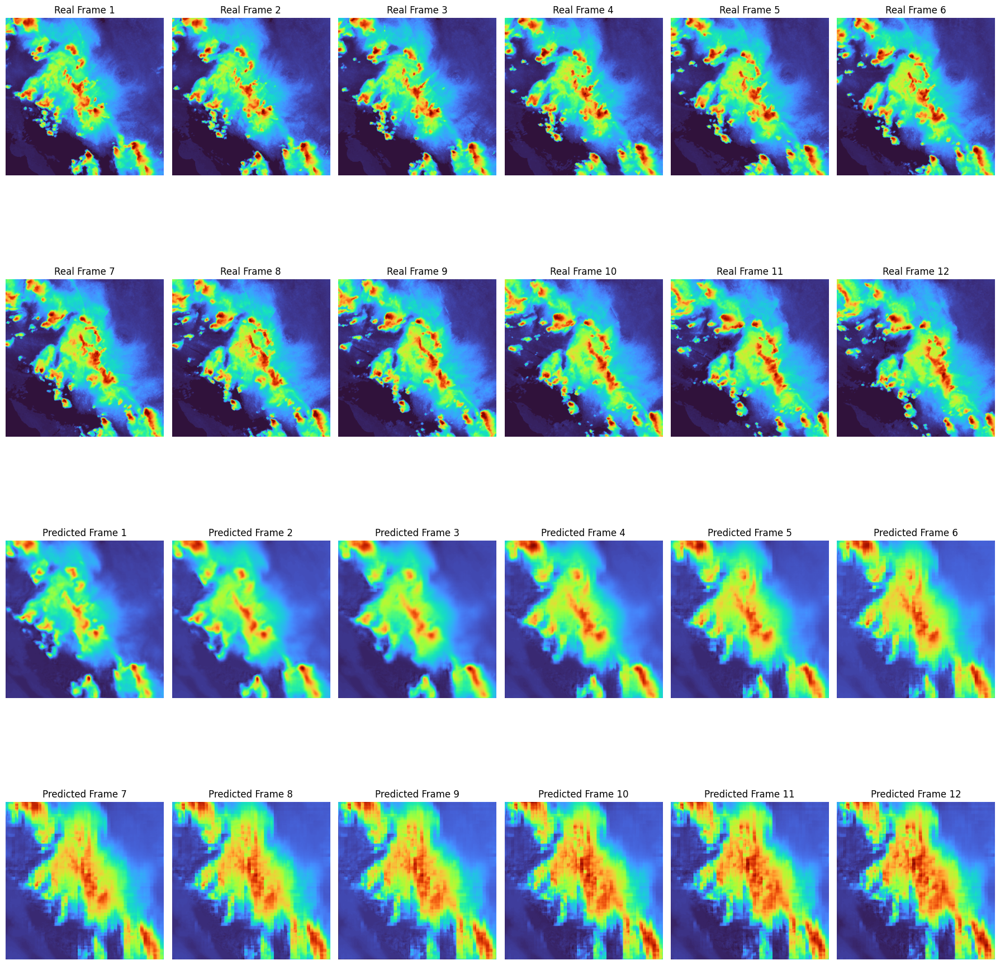

## Basic 3D Convolutional LSTM Model

Build the simple Conv3DLSTM model

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)                         </span>┃<span style="font-weight: bold"> Output Shape                </span>┃<span style="font-weight: bold">         Param # </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │             <span style="color: #00af00; text-decoration-color: #00af00">448</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                    │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                    │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">13,856</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                    │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">55,360</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)             │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">295,168</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">110,720</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">27,680</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>) │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">13,840</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_3 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                    │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>)     │              <span style="color: #00af00; text-decoration-color: #00af00">17</span> │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘
</pre>

Process in model training with 15 epoch, customized loss function

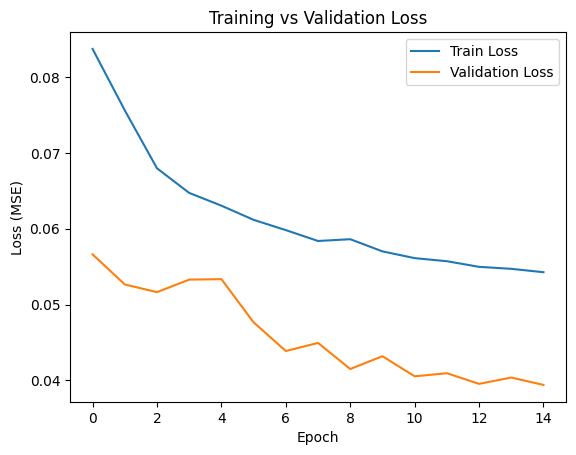

### Explaination
One of the major reasons for val loss being lower is due to the training loss being calculated during training for each epoch, while validation loss is calculated after the training is done, so the model already has previous knowledge about what kind of data you are using and essentially its distribution.

https://ai.stackexchange.com/questions/43383/validation-loss-is-always-lower-than-training-loss-whatever-i-try

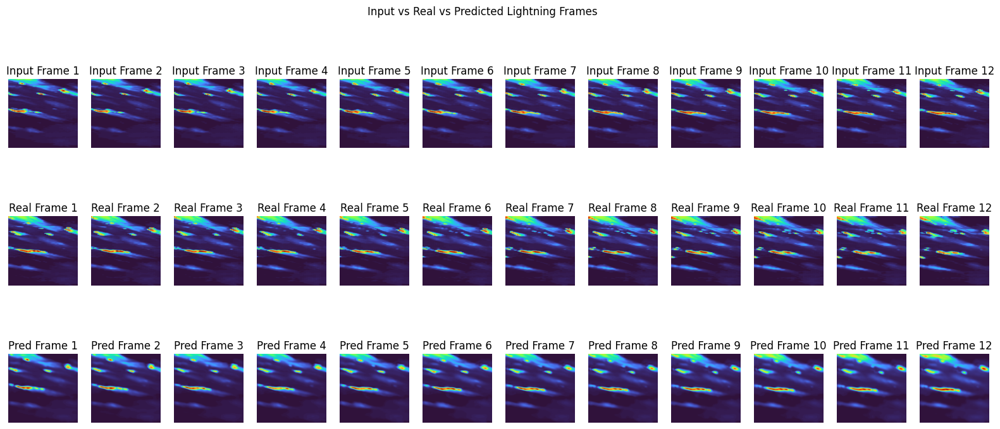

1.	Loss of fine-grained details in predicted frames, leading to blurriness.
2.	Temporal inconsistency in the predictions, meaning the model struggles to fully understand motion.

## Optimising ConvLSTM 

### Discussion

- Depth Scaling:
Increasing the number of ConvLSTM layers to 8 had the most significant impact on improving performance. This is because deeper architectures allow the model to extract progressively richer spatiotemporal features. Since ConvLSTMs are designed to remember patterns over time, additional layers improved their ability to learn long-range dependencies.
- Stride Adjustments:
Adjusting strides in convolutional layers is a known method for downsampling spatial dimensions, reducing computational costs. However, in our case, modifying strides did not significantly impact performance. This is likely because stride changes primarily affect spatial feature extraction rather than sequence modeling, which is the core challenge in this problem.
- Batch Normalization:
While batch normalization is beneficial in CNNs by stabilizing gradients and improving convergence, it showed limited impact on our ConvLSTM model.
- Residual Connections:
Residual connections help mitigate vanishing gradient issues in very deep networks. However, in our case, they did not yield significant improvements. One possible explanation is that ConvLSTMs already have gated mechanisms that control information flow, reducing the necessity for explicit residual links.
- Attention Mechanisms:
Inspired by transformer-based models for weather forecasting, attention layers were considered to selectively focus on the most important spatial-temporal features. However, in earlier experiments, attention blocks did not lead to significant improvements. This may be because attention mechanisms are more useful in cases where the input has complex dependencies across distant frames, whereas our dataset may already contain strong local correlations.
- Learning Rate Scheduling & Batch Size Adjustments:
A dynamic learning rate scheduler (ReduceLROnPlateau) was implemented to prevent stagnation, but in some cases, it led to overly linear loss trends, suggesting that the learning rate was reducing too soon and preventing deeper exploration of the loss landscape.

A batch size of 8/16 was chosen for a balance between gradient stability and generalization while avoiding excessive memory use. The hybrid loss (MSE + SSIM) ensures both pixel-wise accuracy (MSE) and structural integrity (SSIM), preventing overly smooth predictions. SSIM helps preserve sharp edges and textures, crucial for maintaining spatial coherence across frames, while MSE alone would lead to blurry outputs.

### Bigger paddings and strides -> more spatial info preserved -> YES

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)                         </span>┃<span style="font-weight: bold"> Output Shape                </span>┃<span style="font-weight: bold">         Param # </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_78 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │           <span style="color: #00af00; text-decoration-color: #00af00">2,016</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_79 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">64,032</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_80 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">55,360</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_91 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_34 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">295,168</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_92 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_35 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">110,720</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_93 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_34                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">27,680</span> │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_94 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_35                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">13,840</span> │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_95 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_81 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>)     │              <span style="color: #00af00; text-decoration-color: #00af00">17</span> │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘
</pre>

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace"><span style="font-weight: bold"> Total params: </span><span style="color: #00af00; text-decoration-color: #00af00">568,833</span> (2.17 MB)
</pre>

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace"><span style="font-weight: bold"> Trainable params: </span><span style="color: #00af00; text-decoration-color: #00af00">568,833</span> (2.17 MB)
</pre>

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace"><span style="font-weight: bold"> Non-trainable params: </span><span style="color: #00af00; text-decoration-color: #00af00">0</span> (0.00 B)
</pre>

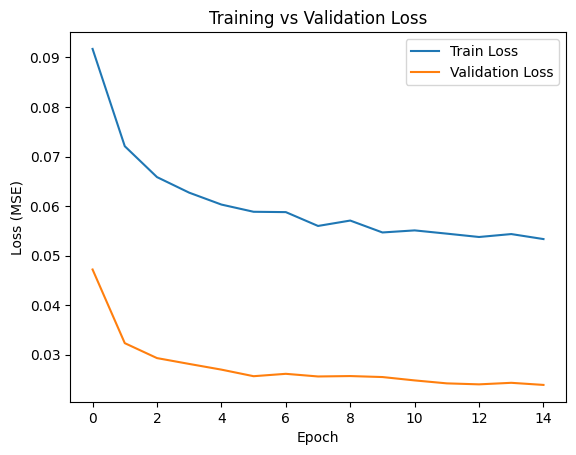

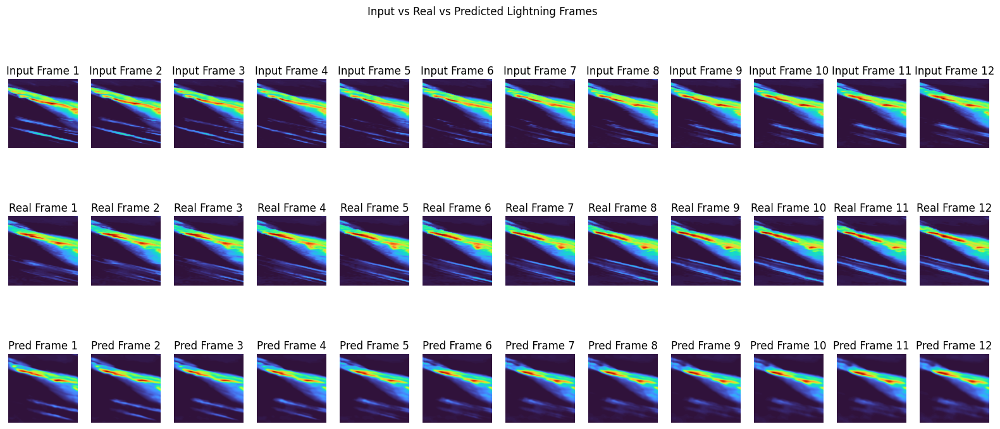

- Sharper Predictions:
- More Accurate Motion Tracking:
- Better Feature Retention

### Add Residual Connections in ConvLSTM Layers X

- Connect x2 to x6 to recover mid-level spatial features.
- Connect x1 to x7 to restore early fine-grained details.

Model Structure

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)              </span>┃<span style="font-weight: bold"> Output Shape           </span>┃<span style="font-weight: bold">        Param # </span>┃<span style="font-weight: bold"> Connected to           </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ -                      │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">InputLayer</span>)              │ <span style="color: #00af00; text-decoration-color: #00af00">1</span>)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_32 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)        │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │          <span style="color: #00af00; text-decoration-color: #00af00">2,016</span> │ input_layer_8[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]    │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">16</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_33 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)        │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>,   │         <span style="color: #00af00; text-decoration-color: #00af00">64,032</span> │ conv3d_32[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">32</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_34 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)        │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │         <span style="color: #00af00; text-decoration-color: #00af00">55,360</span> │ conv3d_33[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_40 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_34[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_lstm2d_16            │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │        <span style="color: #00af00; text-decoration-color: #00af00">295,168</span> │ dropout_40[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_41 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv_lstm2d_16[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_lstm2d_17            │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>) │        <span style="color: #00af00; text-decoration-color: #00af00">110,720</span> │ dropout_41[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_42 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv_lstm2d_17[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_transpose_16       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>,   │         <span style="color: #00af00; text-decoration-color: #00af00">27,680</span> │ dropout_42[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)         │ <span style="color: #00af00; text-decoration-color: #00af00">32</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Add</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_transpose_16[<span style="color: #00af00; text-decoration-color: #00af00">0</span>… │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">32</span>)                    │                │ conv3d_33[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_43 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ add_2[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]            │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">32</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_transpose_17       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │         <span style="color: #00af00; text-decoration-color: #00af00">13,840</span> │ dropout_43[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)         │ <span style="color: #00af00; text-decoration-color: #00af00">16</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (<span style="color: #0087ff; text-decoration-color: #0087ff">Add</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_transpose_17[<span style="color: #00af00; text-decoration-color: #00af00">0</span>… │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">16</span>)                    │                │ conv3d_32[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_44 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ add_3[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]            │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">16</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_35 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)        │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │             <span style="color: #00af00; text-decoration-color: #00af00">17</span> │ dropout_44[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">1</span>)                     │                │                        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘
</pre>

Training Loss with 15 epoch

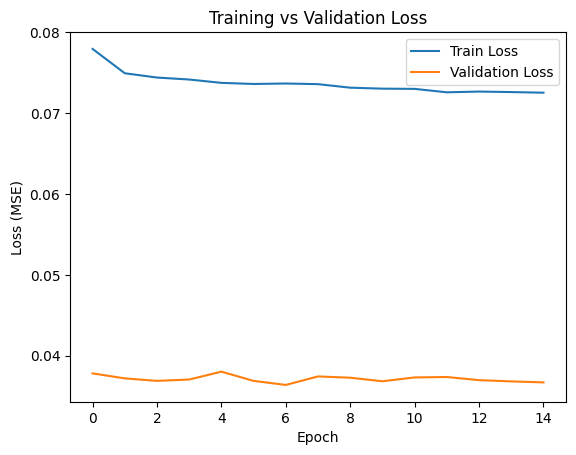

Prediction 

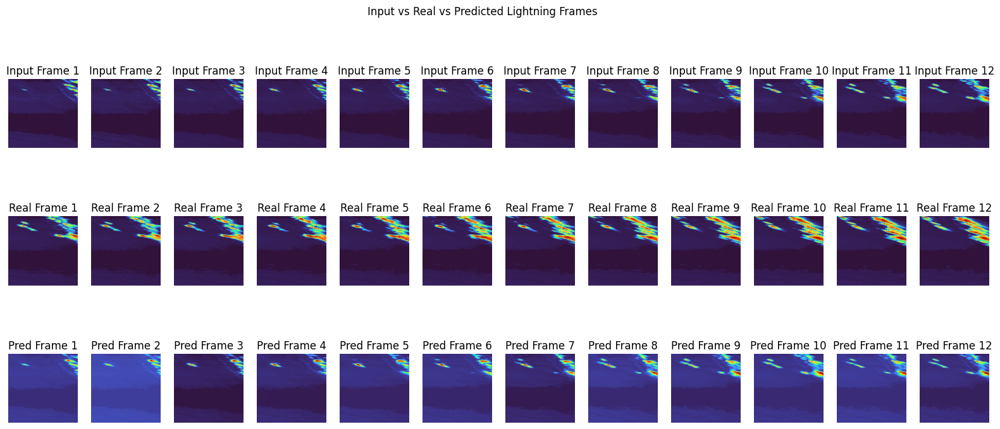

Since the image quality is evidently reduced I will not use skip connections. I think model is not deep enough to make much of a difference.

### Attention blocks X

We asked chatgpt for help and it suggesting uisng  Squeeze-and-Excitation (SE) Attention Blocks.
- After ConvLSTM layers and conv layers.
- Improves motion continuity across frames.

Model Structure

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)              </span>┃<span style="font-weight: bold"> Output Shape           </span>┃<span style="font-weight: bold">        Param # </span>┃<span style="font-weight: bold"> Connected to           </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15            │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ -                      │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">InputLayer</span>)              │ <span style="color: #00af00; text-decoration-color: #00af00">1</span>)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_51 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)        │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │          <span style="color: #00af00; text-decoration-color: #00af00">2,016</span> │ input_layer_15[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]   │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">16</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)             │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_51[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">GlobalAveragePooling3D</span>)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)             │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">8</span>)              │            <span style="color: #00af00; text-decoration-color: #00af00">136</span> │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)             │            <span style="color: #00af00; text-decoration-color: #00af00">144</span> │ dense[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (<span style="color: #0087ff; text-decoration-color: #0087ff">Reshape</span>)         │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ dense_1[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (<span style="color: #0087ff; text-decoration-color: #0087ff">Multiply</span>)       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_51[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>],       │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">16</span>)                    │                │ reshape[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_52 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)        │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>,   │         <span style="color: #00af00; text-decoration-color: #00af00">64,032</span> │ multiply[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]         │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">32</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d… │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)             │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_52[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">GlobalAveragePooling3D</span>)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)             │            <span style="color: #00af00; text-decoration-color: #00af00">528</span> │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)             │            <span style="color: #00af00; text-decoration-color: #00af00">544</span> │ dense_2[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Reshape</span>)       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ dense_3[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Multiply</span>)     │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_52[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>],       │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">32</span>)                    │                │ reshape_1[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_53 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)        │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │         <span style="color: #00af00; text-decoration-color: #00af00">55,360</span> │ multiply_1[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d… │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)             │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_53[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">GlobalAveragePooling3D</span>)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)             │          <span style="color: #00af00; text-decoration-color: #00af00">2,080</span> │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)             │          <span style="color: #00af00; text-decoration-color: #00af00">2,112</span> │ dense_4[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Reshape</span>)       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)    │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ dense_5[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Multiply</span>)     │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_53[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>],       │
│                           │                        │                │ reshape_2[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_63 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ multiply_2[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_54 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)        │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │        <span style="color: #00af00; text-decoration-color: #00af00">110,656</span> │ dropout_63[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_lstm2d_27            │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │        <span style="color: #00af00; text-decoration-color: #00af00">295,168</span> │ conv3d_54[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d… │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)             │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv_lstm2d_27[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]   │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">GlobalAveragePooling3D</span>)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)             │          <span style="color: #00af00; text-decoration-color: #00af00">2,080</span> │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)             │          <span style="color: #00af00; text-decoration-color: #00af00">2,112</span> │ dense_6[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_3 (<span style="color: #0087ff; text-decoration-color: #0087ff">Reshape</span>)       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)    │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ dense_7[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_3 (<span style="color: #0087ff; text-decoration-color: #0087ff">Multiply</span>)     │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv_lstm2d_27[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>],  │
│                           │                        │                │ reshape_3[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_64 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ multiply_3[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_lstm2d_28            │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>) │        <span style="color: #00af00; text-decoration-color: #00af00">110,720</span> │ dropout_64[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d… │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)             │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv_lstm2d_28[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]   │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">GlobalAveragePooling3D</span>)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)             │            <span style="color: #00af00; text-decoration-color: #00af00">528</span> │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)           │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)             │            <span style="color: #00af00; text-decoration-color: #00af00">544</span> │ dense_8[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_4 (<span style="color: #0087ff; text-decoration-color: #0087ff">Reshape</span>)       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ dense_9[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_4 (<span style="color: #0087ff; text-decoration-color: #0087ff">Multiply</span>)     │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv_lstm2d_28[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>],  │
│                           │                        │                │ reshape_4[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_65 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ multiply_4[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_lstm2d_29            │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>) │         <span style="color: #00af00; text-decoration-color: #00af00">73,856</span> │ dropout_65[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_66 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>) │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv_lstm2d_29[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_transpose_24       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>,   │         <span style="color: #00af00; text-decoration-color: #00af00">27,680</span> │ dropout_66[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)         │ <span style="color: #00af00; text-decoration-color: #00af00">32</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d… │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)             │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_transpose_24[<span style="color: #00af00; text-decoration-color: #00af00">0</span>… │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">GlobalAveragePooling3D</span>)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)             │            <span style="color: #00af00; text-decoration-color: #00af00">528</span> │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)             │            <span style="color: #00af00; text-decoration-color: #00af00">544</span> │ dense_10[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_5 (<span style="color: #0087ff; text-decoration-color: #0087ff">Reshape</span>)       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ dense_11[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_5 (<span style="color: #0087ff; text-decoration-color: #0087ff">Multiply</span>)     │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_transpose_24[<span style="color: #00af00; text-decoration-color: #00af00">0</span>… │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">32</span>)                    │                │ reshape_5[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_67 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ multiply_5[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">32</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_transpose_25       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │         <span style="color: #00af00; text-decoration-color: #00af00">13,840</span> │ dropout_67[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)         │ <span style="color: #00af00; text-decoration-color: #00af00">16</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d… │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)             │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_transpose_25[<span style="color: #00af00; text-decoration-color: #00af00">0</span>… │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">GlobalAveragePooling3D</span>)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">8</span>)              │            <span style="color: #00af00; text-decoration-color: #00af00">136</span> │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)             │            <span style="color: #00af00; text-decoration-color: #00af00">144</span> │ dense_12[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_6 (<span style="color: #0087ff; text-decoration-color: #0087ff">Reshape</span>)       │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ dense_13[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_6 (<span style="color: #0087ff; text-decoration-color: #0087ff">Multiply</span>)     │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ conv3d_transpose_25[<span style="color: #00af00; text-decoration-color: #00af00">0</span>… │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">16</span>)                    │                │ reshape_6[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_68 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │              <span style="color: #00af00; text-decoration-color: #00af00">0</span> │ multiply_6[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">16</span>)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_55 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)        │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>,   │             <span style="color: #00af00; text-decoration-color: #00af00">17</span> │ dropout_68[<span style="color: #00af00; text-decoration-color: #00af00">0</span>][<span style="color: #00af00; text-decoration-color: #00af00">0</span>]       │
│                           │ <span style="color: #00af00; text-decoration-color: #00af00">1</span>)                     │                │                        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘
</pre>

Training process

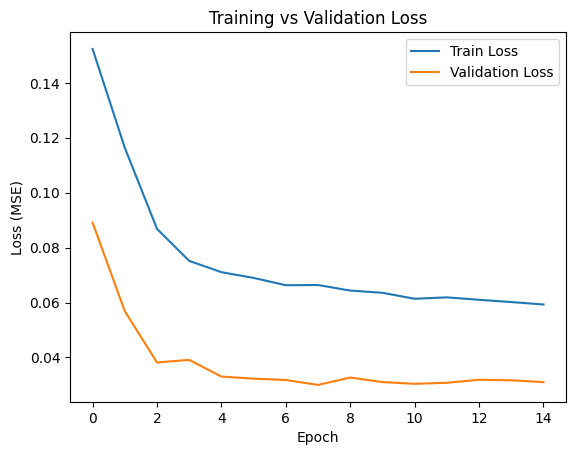

Prediction Results:

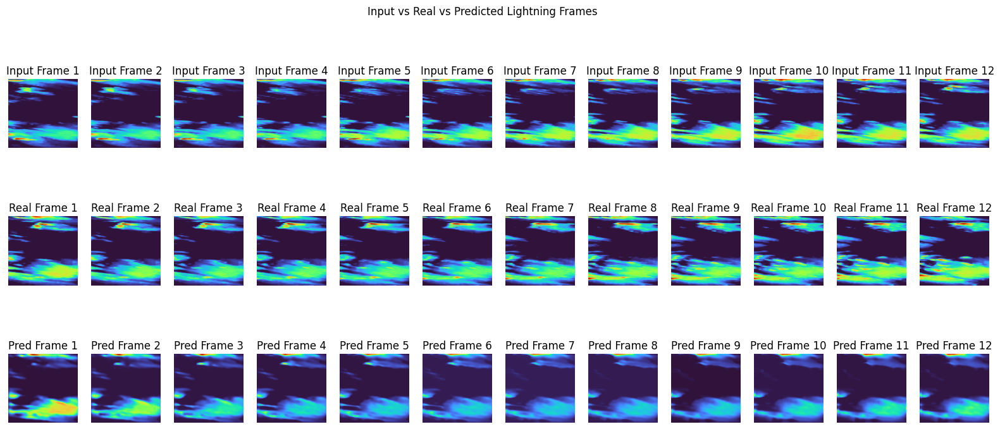

If all spatial regions contribute equally, attention may not be beneficial. Attention forces for feature selection based on spatial patterns might be interfering with motion/frame-to-frame learning.

Let's try removing the attention block to the encoder and decoder bit.  

### BidirectionalConvLSTM2D X

We train model which processes the sequence in both directions: forward (from start to end) and backward (from end to start)

Model Structure

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)                         </span>┃<span style="font-weight: bold"> Output Shape                </span>┃<span style="font-weight: bold">         Param # </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_74 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │           <span style="color: #00af00; text-decoration-color: #00af00">2,016</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_75 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">64,032</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_76 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">55,360</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_86 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Bidirectional</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)     │         <span style="color: #00af00; text-decoration-color: #00af00">590,336</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_87 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)     │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (<span style="color: #0087ff; text-decoration-color: #0087ff">Bidirectional</span>)      │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">368,896</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_88 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_32                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">55,328</span> │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_89 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_33                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">13,840</span> │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_90 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_77 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>)     │              <span style="color: #00af00; text-decoration-color: #00af00">17</span> │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘
</pre>

Training loss

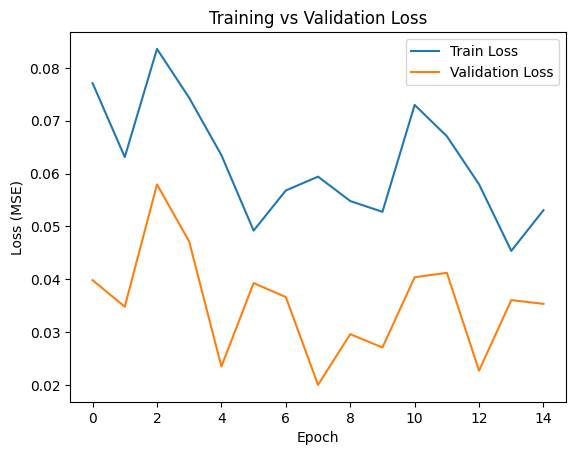

Prediction 

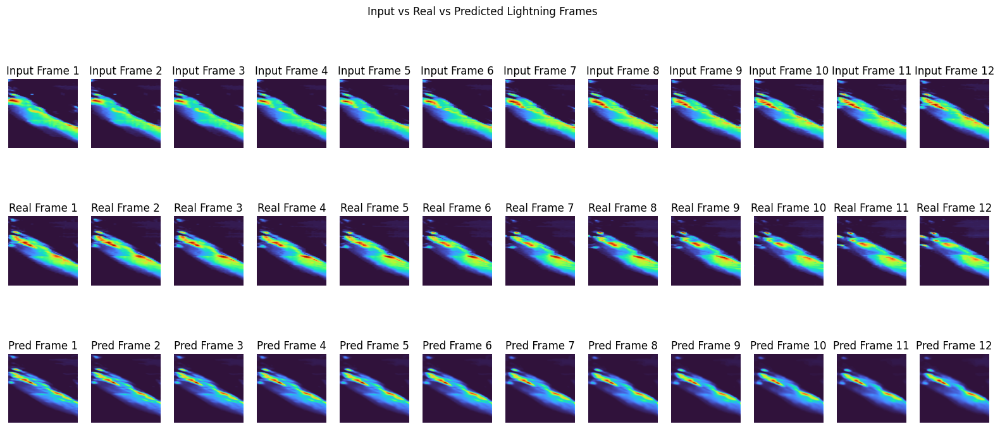

### Add more convlstm layers(4 layers)

Model Structure

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)                         </span>┃<span style="font-weight: bold"> Output Shape                </span>┃<span style="font-weight: bold">         Param # </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_24 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │           <span style="color: #00af00; text-decoration-color: #00af00">2,016</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_25 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">64,032</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_26 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">55,360</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_58 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_34 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)     │         <span style="color: #00af00; text-decoration-color: #00af00">885,248</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_59 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)     │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_35 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">442,624</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_60 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_36 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">110,720</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_61 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_37 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">73,856</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_62 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_18                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">55,360</span> │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_63 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_19                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">55,328</span> │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_64 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_20                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">13,840</span> │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_65 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_27 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>)     │              <span style="color: #00af00; text-decoration-color: #00af00">17</span> │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘
</pre>

Training Process

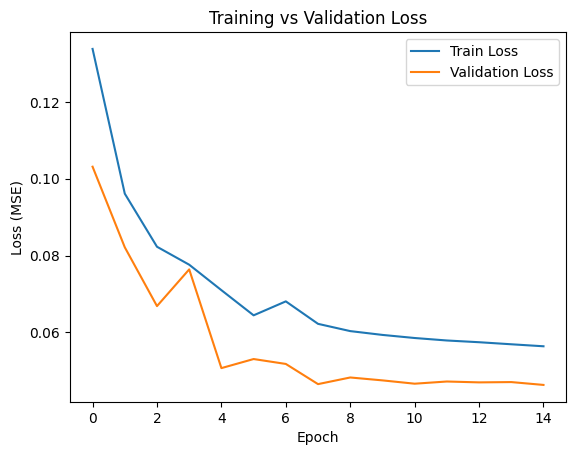

Oscillations, especially in the earlier epochs.
This can be due to:
- High Learning Rate? Model makes large updates, causing fluctuations.
- ConvLSTM layers suffer from unstable gradients.
- Too much randomness in neuron activations.

Predict Result:

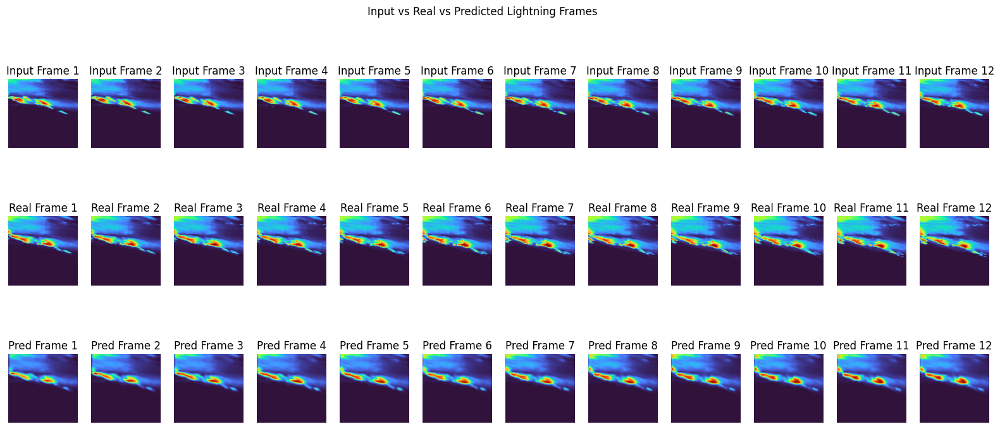

### Reducing learning rate dynamically X

Training Process

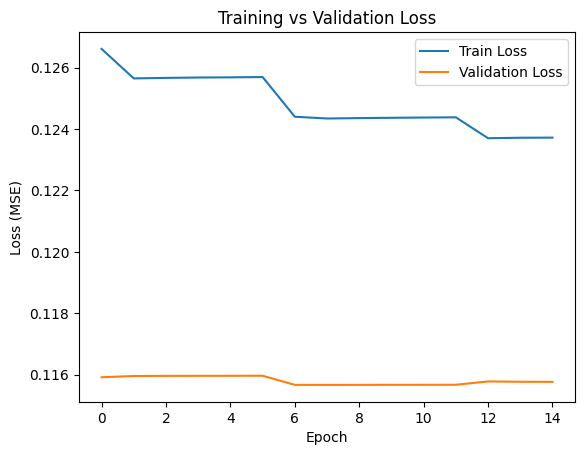

Training Result

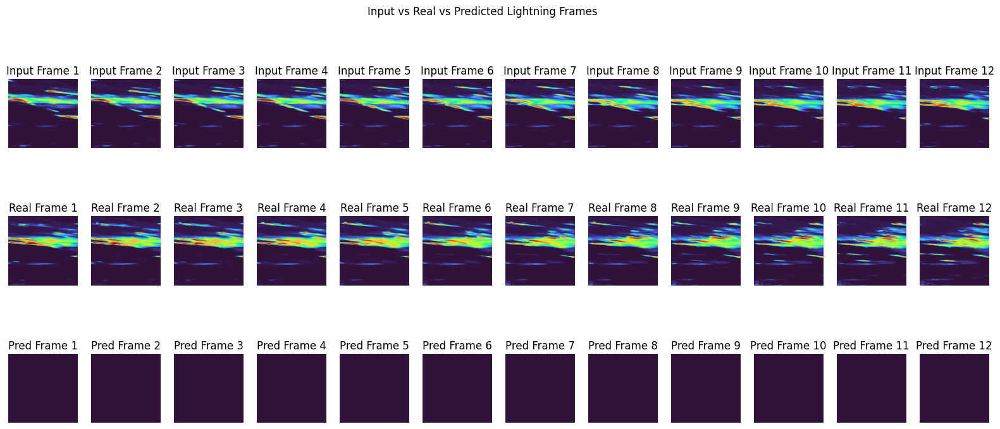

Worst yet.

### Even more convlstm layers -> X(result: crash memory)

Model:

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)                         </span>┃<span style="font-weight: bold"> Output Shape                </span>┃<span style="font-weight: bold">         Param # </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_12 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │           <span style="color: #00af00; text-decoration-color: #00af00">2,016</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_13 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">64,032</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_14 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">55,360</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_18 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)     │         <span style="color: #00af00; text-decoration-color: #00af00">885,248</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)     │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_19 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)     │       <span style="color: #00af00; text-decoration-color: #00af00">1,180,160</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)     │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_20 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">442,624</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_21 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">295,168</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_22 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │         <span style="color: #00af00; text-decoration-color: #00af00">110,720</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_23 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">73,856</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_36 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_24 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">27,712</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_37 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_25 (<span style="color: #0087ff; text-decoration-color: #0087ff">ConvLSTM2D</span>)          │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)      │          <span style="color: #00af00; text-decoration-color: #00af00">18,496</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_38 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">96</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)      │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_9 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>) │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">27,712</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_39 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_10                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">55,328</span> │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_40 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">192</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_transpose_11                  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │          <span style="color: #00af00; text-decoration-color: #00af00">13,840</span> │
│ (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3DTranspose</span>)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_41 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">16</span>)    │               <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_15 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv3D</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">12</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">384</span>, <span style="color: #00af00; text-decoration-color: #00af00">1</span>)     │              <span style="color: #00af00; text-decoration-color: #00af00">17</span> │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘
</pre>

Model training fail since memory crash

### Explainability (Final Model)

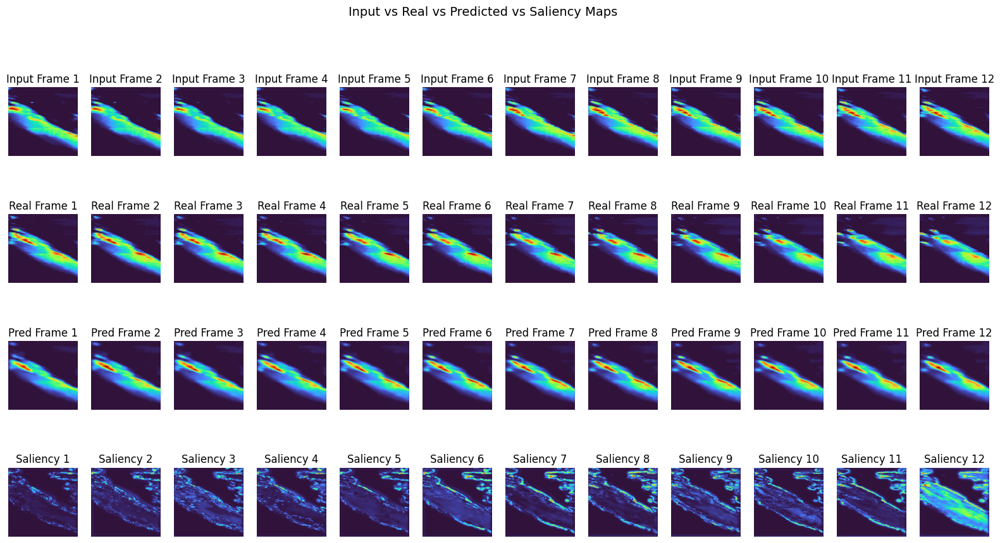

The results provide a clear comparison between the input frames, ground truth (real) frames, predicted frames, and their respective saliency maps. The predicted frames closely follow the real frames, indicating that the model has learned meaningful spatial and temporal patterns from the input sequence. However, slight discrepancies in finer details suggest areas where prediction accuracy could be improved. The saliency maps highlight the regions in the input frames that had the most influence on the predicted outputs. These maps show strong activation along the bright lightning structures, confirming that the model is focusing on relevant spatial features rather than noise. Notably, the saliency intensity varies across frames, suggesting that some frames contribute more to the predictions than others. This analysis helps in assessing both model reliability and interpretability, potentially guiding improvements such as refining attention mechanisms or incorporating additional spatiotemporal constraints.

Since the saliency maps show meaningful attention on key regions, the issue of the attention layer is likely not in missing dependencies—but rather where, how, and when attention is applied.

## Outlook and Conclusion

While U-Nets and CNN-LSTMs provide a solid foundation for spatiotemporal forecasting, they come with inherent limitations. U-Nets, although powerful for spatial feature extraction, struggle with long-term temporal dependencies as they treat time implicitly, leading to drifting predictions in later frames. CNN-LSTMs, on the other hand, explicitly model temporal dependencies but are computationally expensive, prone to vanishing gradients, and can struggle with capturing long-range dependencies effectively.

Recent research suggests alternative architectures that could further improve performance. Transformer-based models, such as Video Vision Transformers (ViTs) or Temporal Attention Networks, can capture global temporal dependencies more effectively than recurrent models. Additionally, Diffusion Models and GAN-based architectures have shown promise in generating high-resolution, temporally consistent video frames by learning latent distributions. Hybrid approaches like ConvLSTM + Transformer hybrids could also enhance temporal learning while retaining localized spatial feature extraction.https://www.researchgate.net/publication/373987811_Comprehensive_Transformer-Based_Model_Architecture_for_Real-World_Storm_Prediction

Morevoer, another idea would be to explore other methods of data augmentation, temporally-wise and spatially-wise, suchas rotations and time series interpolation since we are given frames that are 5 minutes apart.
